<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session07: Linear Regression & Gradient Descent</font></h3>
<h3 align="center">Zahra Amini</h3>

# PART00

# Step0: Import Libraries

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn import metrics

import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Step1: Read Data

In [2]:
df = pd.read_csv("houses.csv")

In [3]:
df.head()

,size(sqft),bedrooms,floors,age,price
0,952.0,2.0,1.0,65.0,271.5
1,1244.0,3.0,1.0,64.0,300.0
2,1947.0,3.0,2.0,17.0,509.8
3,1725.0,3.0,2.0,42.0,394.0
4,1959.0,3.0,2.0,15.0,540.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   size(sqft)  100 non-null    float64
 1   bedrooms    100 non-null    float64
 2   floors      100 non-null    float64
 3   age         100 non-null    float64
 4   price       100 non-null    float64
dtypes: float64(5)
memory usage: 4.0 KB


# Step2: X, y

In [5]:
X = df.drop('price', axis=1)

In [6]:
y = df['price']

In [7]:
X.shape

(100, 4)

In [8]:
y.shape

(100,)

# Step3: Split Trainset and Testset (X_train, X_test, y_train, y_test)
<hr>
<b>from sklearn.model_selection import train_test_split</b>

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [10]:
X_train.shape

(80, 4)

In [11]:
X_test.shape

(20, 4)

# Step4: Data Visualization

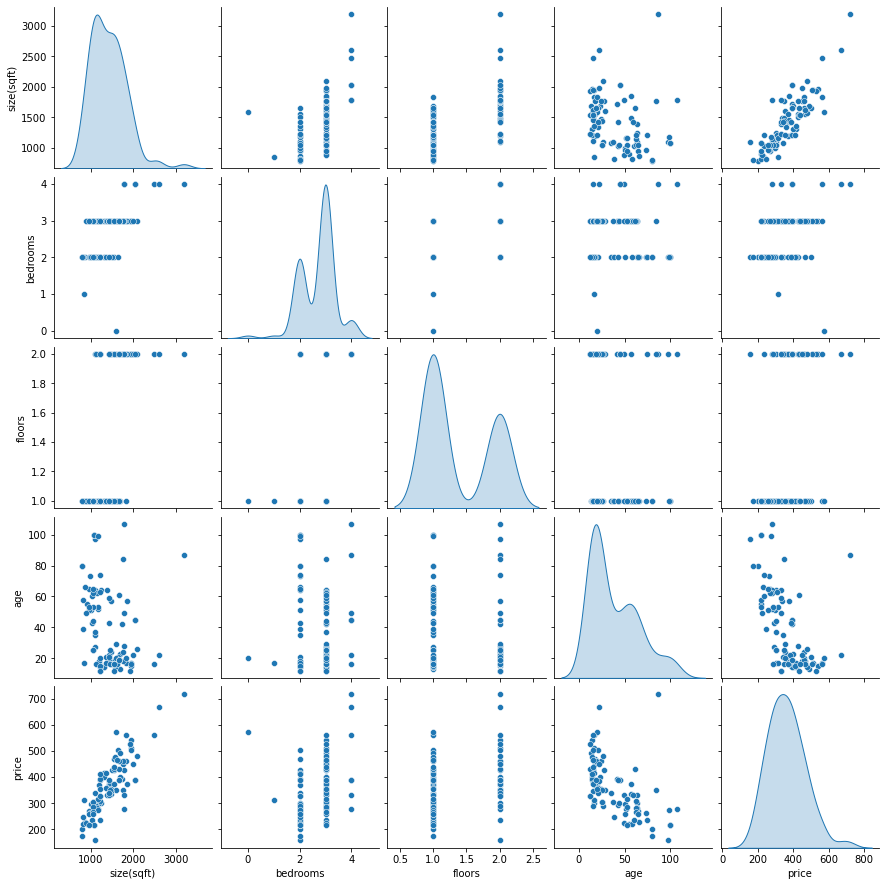

In [12]:
sns.pairplot(df, diag_kind = 'kde')

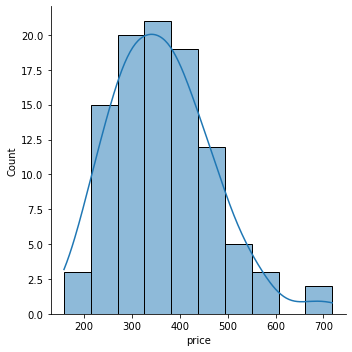

In [13]:
sns.displot(data=df, x='price', kde=True)

# PART01: LR

# Step5: Create the model
<b>linear regression</b>
<hr>
<b>from sklearn.linear_model import LinearRegression</b>

In [14]:
LR = LinearRegression()

# Step6: Training the model

In [15]:
LR.fit(X_train, y_train)

LinearRegression()

In [16]:
LR.coef_

array([  0.26618701, -33.38750502, -67.37775474,  -1.36733828])

In [17]:
LR.intercept_

222.3200392079513

# Step7: Predicting Test Data

In [18]:
y_pred = LR.predict(X_test)

In [19]:
y_pred

array([324.03661268, 298.40675938, 237.05210788, 237.05210788,
       463.06056408, 329.92190094, 403.29302292, 372.39538357,
       227.9085243 , 432.84391619, 353.09288785, 296.19540245,
       485.38783149, 615.75310485, 402.17588724, 293.51985794,
       453.81682521, 486.06581842, 389.14639819, 226.07025406])

In [20]:
y_test

16    311.800
1     300.000
43    216.960
67    216.960
89    464.000
21    340.000
97    390.000
51    334.000
6     230.000
41    390.000
82    378.000
25    304.000
45    504.000
68    666.336
37    374.000
31    280.000
50    478.000
32    526.870
3     394.000
48    220.000
Name: price, dtype: float64

# Step8: Evalutaing the Model
<hr>
<br>from sklearn import metrics</br>

In [21]:
MAE = metrics.mean_absolute_error(y_test, y_pred)

In [22]:
MAE

19.05845665984373

In [23]:
MSE = metrics.mean_squared_error(y_test, y_pred)

In [24]:
MSE

571.3096278300098

In [25]:
RMSE = np.sqrt(MSE)

In [26]:
RMSE

23.90208417335212

# PART02: GD

# Step9: Scale Data
<hr>
<b>from sklearn.preprocessing import StandardScaler</b>

In [27]:
scaler = StandardScaler()

In [28]:
scaler.fit(X_train)

StandardScaler()

In [29]:
X_train_s = scaler.transform(X_train)

In [30]:
X_test_s = scaler.transform(X_test)

# Step10: RUN GD

In [31]:
def cost_function(x, y, W, b):
    m = x.shape[0]
    
    f_wb = np.dot(x, W) + b
    
    error = f_wb - y
    
    J = 1/(2*m) * np.sum(error ** 2)
    
    return J, error

In [32]:
J_hist = [0.1]

In [33]:
n_iter = 10000
J_h = np.zeros((n_iter+1,2))

In [34]:
def gradient(alpha, x, y, n_iter):
    
    m = x.shape[0]
    W = np.ones(X.shape[1])
    b=0
    
    for iter in range(0, n_iter):
        J, error = cost_function(x, y, W, b)
        
        J_hist.append(J)
        
        print("iter:",iter,"J:", J )
        
        J_h[iter, 1] = iter
        J_h[iter, 0] = J
        
        if(J_hist[iter+1] - J_hist[iter]==0):
            break
            
        dj_dw = 1/m * np.dot(x.T, error)
        
        dj_db = 1/m * np.sum(error)
        
        W = W- alpha * dj_dw
        
        b = b- alpha * dj_db
        
    return W,b

# Step11: Plots

In [35]:
x, y = X_train_s, y_train

alpha=0.01

W, b = gradient(alpha, x, y, n_iter)


for i in range(x.shape[1]):
    y_prediction = X_test_s[:, [0]]*W[0]+b

iter: 0 J: 70320.61772213987
iter: 1 J: 68914.77511027957
iter: 2 J: 67538.05842804564
iter: 3 J: 66189.83772584004
iter: 4 J: 64869.497583968594
iter: 5 J: 63576.436746006635
iter: 6 J: 62310.06776246079
iter: 7 J: 61069.81664440573
iter: 8 J: 59855.12252678585
iter: 9 J: 58665.43734108249
iter: 10 J: 57500.225497057036
iter: 11 J: 56358.9635732902
iter: 12 J: 55241.14001624722
iter: 13 J: 54146.25484760769
iter: 14 J: 53073.81937960748
iter: 15 J: 52023.3559381486
iter: 16 J: 50994.39759344134
iter: 17 J: 49986.487897950086
iter: 18 J: 48999.18063142275
iter: 19 J: 48032.03955279022
iter: 20 J: 47084.63815872984
iter: 21 J: 46156.559448693355
iter: 22 J: 45247.39569620652
iter: 23 J: 44356.748226253876
iter: 24 J: 43484.22719856809
iter: 25 J: 42629.451396649514
iter: 26 J: 41792.048022346906
iter: 27 J: 40971.652495836024
iter: 28 J: 40167.90826083797
iter: 29 J: 39380.46659492421
iter: 30 J: 38608.98642476036
iter: 31 J: 37853.134146145276
iter: 32 J: 37112.58344870678
iter: 33 J: 

iter: 324 J: 459.0633702556139
iter: 325 J: 455.9019187914806
iter: 326 J: 452.7889900286868
iter: 327 J: 449.7237323960701
iter: 328 J: 446.7053103664537
iter: 329 J: 443.73290414439583
iter: 330 J: 440.8057093601063
iter: 331 J: 437.9229367693983
iter: 332 J: 435.0838119595685
iter: 333 J: 432.28757506107763
iter: 334 J: 429.53348046492215
iter: 335 J: 426.82079654557685
iter: 336 J: 424.14880538940736
iter: 337 J: 421.51680252843516
iter: 338 J: 418.9240966793543
iter: 339 J: 416.37000948769423
iter: 340 J: 413.8538752770253
iter: 341 J: 411.3750408031052
iter: 342 J: 408.9328650128741
iter: 343 J: 406.52671880819616
iter: 344 J: 404.1559848142586
iter: 345 J: 401.82005715252774
iter: 346 J: 399.51834121818143
iter: 347 J: 397.250253461924
iter: 348 J: 395.0152211760913
iter: 349 J: 392.81268228497737
iter: 350 J: 390.642085139277
iter: 351 J: 388.5028883145781
iter: 352 J: 386.3945604138227
iter: 353 J: 384.3165798736478
iter: 354 J: 382.26843477453866
iter: 355 J: 380.249622654717

iter: 669 J: 218.7510039425514
iter: 670 J: 218.6716853180095
iter: 671 J: 218.5930166923302
iter: 672 J: 218.51499246705836
iter: 673 J: 218.4376070971404
iter: 674 J: 218.3608550903224
iter: 675 J: 218.28473100655316
iter: 676 J: 218.2092294573985
iter: 677 J: 218.13434510546213
iter: 678 J: 218.0600726638134
iter: 679 J: 217.986406895426
iter: 680 J: 217.91334261262156
iter: 681 J: 217.84087467652125
iter: 682 J: 217.7689979965072
iter: 683 J: 217.69770752968753
iter: 684 J: 217.62699828037168
iter: 685 J: 217.55686529955133
iter: 686 J: 217.48730368438896
iter: 687 J: 217.41830857771257
iter: 688 J: 217.3498751675179
iter: 689 J: 217.2819986864769
iter: 690 J: 217.21467441145307
iter: 691 J: 217.14789766302306
iter: 692 J: 217.08166380500361
iter: 693 J: 217.01596824398763
iter: 694 J: 216.95080642888263
iter: 695 J: 216.88617385045825
iter: 696 J: 216.82206604089788
iter: 697 J: 216.75847857335725
iter: 698 J: 216.69540706152844
iter: 699 J: 216.63284715920864
iter: 700 J: 216.570

iter: 972 J: 209.74523683403123
iter: 973 J: 209.73823422470468
iter: 974 J: 209.73128696884532
iter: 975 J: 209.72439462818397
iter: 976 J: 209.71755676793464
iter: 977 J: 209.7107729567672
iter: 978 J: 209.70404276677937
iter: 979 J: 209.69736577346987
iter: 980 J: 209.6907415557097
iter: 981 J: 209.68416969571655
iter: 982 J: 209.67764977902763
iter: 983 J: 209.67118139447263
iter: 984 J: 209.6647641341474
iter: 985 J: 209.65839759338826
iter: 986 J: 209.6520813707456
iter: 987 J: 209.64581506795832
iter: 988 J: 209.63959828992822
iter: 989 J: 209.63343064469495
iter: 990 J: 209.62731174341008
iter: 991 J: 209.62124120031322
iter: 992 J: 209.615218632707
iter: 993 J: 209.60924366093195
iter: 994 J: 209.60331590834267
iter: 995 J: 209.59743500128423
iter: 996 J: 209.59160056906705
iter: 997 J: 209.58581224394425
iter: 998 J: 209.58006966108783
iter: 999 J: 209.57437245856454
iter: 1000 J: 209.5687202773147
iter: 1001 J: 209.56311276112658
iter: 1002 J: 209.55754955661578
iter: 1003 J

iter: 1337 J: 208.90783398424247
iter: 1338 J: 208.9074463626259
iter: 1339 J: 208.90706180129183
iter: 1340 J: 208.90668027607776
iter: 1341 J: 208.90630176301238
iter: 1342 J: 208.90592623831327
iter: 1343 J: 208.90555367838613
iter: 1344 J: 208.9051840598228
iter: 1345 J: 208.90481735940003
iter: 1346 J: 208.90445355407783
iter: 1347 J: 208.9040926209984
iter: 1348 J: 208.90373453748396
iter: 1349 J: 208.90337928103622
iter: 1350 J: 208.90302682933466
iter: 1351 J: 208.9026771602342
iter: 1352 J: 208.90233025176576
iter: 1353 J: 208.90198608213268
iter: 1354 J: 208.90164462971103
iter: 1355 J: 208.9013058730476
iter: 1356 J: 208.9009697908581
iter: 1357 J: 208.90063636202694
iter: 1358 J: 208.9003055656051
iter: 1359 J: 208.8999773808084
iter: 1360 J: 208.89965178701743
iter: 1361 J: 208.89932876377526
iter: 1362 J: 208.89900829078667
iter: 1363 J: 208.8986903479167
iter: 1364 J: 208.89837491518912
iter: 1365 J: 208.89806197278585
iter: 1366 J: 208.89775150104484
iter: 1367 J: 208.8

...

iter: 2438 J: 208.85874357330397
iter: 2439 J: 208.8587435104147
iter: 2440 J: 208.85874344802187
iter: 2441 J: 208.8587433861214
iter: 2442 J: 208.85874332470985
iter: 2443 J: 208.85874326378308
iter: 2444 J: 208.8587432033372
iter: 2445 J: 208.85874314336863
iter: 2446 J: 208.85874308387338
iter: 2447 J: 208.85874302484783
iter: 2448 J: 208.85874296628822
iter: 2449 J: 208.85874290819103
iter: 2450 J: 208.85874285055235
iter: 2451 J: 208.85874279336872
iter: 2452 J: 208.8587427366365
iter: 2453 J: 208.85874268035232
iter: 2454 J: 208.85874262451236
iter: 2455 J: 208.8587425691133
iter: 2456 J: 208.85874251415146
iter: 2457 J: 208.8587424596235
iter: 2458 J: 208.85874240552621
iter: 2459 J: 208.85874235185577
iter: 2460 J: 208.8587422986092
iter: 2461 J: 208.85874224578288
iter: 2462 J: 208.85874219337353
iter: 2463 J: 208.85874214137812
iter: 2464 J: 208.85874208979305
iter: 2465 J: 208.85874203861522
iter: 2466 J: 208.8587419878415
iter: 2467 J: 208.8587419374686
iter: 2468 J: 208.8

iter: 2806 J: 208.85873603812925
iter: 2807 J: 208.858736034726
iter: 2808 J: 208.85873603134993
iter: 2809 J: 208.8587360280003
iter: 2810 J: 208.85873602467723
iter: 2811 J: 208.85873602138028
iter: 2812 J: 208.8587360181093
iter: 2813 J: 208.85873601486443
iter: 2814 J: 208.85873601164505
iter: 2815 J: 208.858736008451
iter: 2816 J: 208.85873600528222
iter: 2817 J: 208.85873600213847
iter: 2818 J: 208.85873599901944
iter: 2819 J: 208.85873599592512
iter: 2820 J: 208.85873599285526
iter: 2821 J: 208.85873598980953
iter: 2822 J: 208.85873598678796
iter: 2823 J: 208.85873598379013
iter: 2824 J: 208.85873598081608
iter: 2825 J: 208.8587359778655
iter: 2826 J: 208.8587359749381
iter: 2827 J: 208.8587359720339
iter: 2828 J: 208.85873596915255
iter: 2829 J: 208.858735966294
iter: 2830 J: 208.858735963458
iter: 2831 J: 208.85873596064448
iter: 2832 J: 208.85873595785313
iter: 2833 J: 208.85873595508372
iter: 2834 J: 208.85873595233625
iter: 2835 J: 208.85873594961046
iter: 2836 J: 208.85873

iter: 3160 J: 208.85873563312134
iter: 3161 J: 208.8587356329158
iter: 3162 J: 208.85873563271153
iter: 3163 J: 208.858735632509
iter: 3164 J: 208.85873563230803
iter: 3165 J: 208.85873563210882
iter: 3166 J: 208.8587356319111
iter: 3167 J: 208.85873563171492
iter: 3168 J: 208.8587356315201
iter: 3169 J: 208.85873563132702
iter: 3170 J: 208.85873563113557
iter: 3171 J: 208.85873563094538
iter: 3172 J: 208.85873563075677
iter: 3173 J: 208.85873563056967
iter: 3174 J: 208.85873563038405
iter: 3175 J: 208.85873563019993
iter: 3176 J: 208.85873563001735
iter: 3177 J: 208.858735629836
iter: 3178 J: 208.85873562965622
iter: 3179 J: 208.8587356294778
iter: 3180 J: 208.85873562930075
iter: 3181 J: 208.85873562912522
iter: 3182 J: 208.85873562895077
iter: 3183 J: 208.8587356287782
iter: 3184 J: 208.8587356286066
iter: 3185 J: 208.85873562843665
iter: 3186 J: 208.85873562826774
iter: 3187 J: 208.8587356281004
iter: 3188 J: 208.85873562793424
iter: 3189 J: 208.85873562776925
iter: 3190 J: 208.858

iter: 3524 J: 208.8587356085138
iter: 3525 J: 208.85873560850212
iter: 3526 J: 208.8587356084907
iter: 3527 J: 208.8587356084795
iter: 3528 J: 208.85873560846824
iter: 3529 J: 208.85873560845704
iter: 3530 J: 208.85873560844604
iter: 3531 J: 208.85873560843513
iter: 3532 J: 208.85873560842415
iter: 3533 J: 208.8587356084133
iter: 3534 J: 208.85873560840264
iter: 3535 J: 208.85873560839207
iter: 3536 J: 208.85873560838155
iter: 3537 J: 208.8587356083711
iter: 3538 J: 208.8587356083608
iter: 3539 J: 208.85873560835034
iter: 3540 J: 208.85873560834023
iter: 3541 J: 208.85873560833002
iter: 3542 J: 208.85873560832016
iter: 3543 J: 208.85873560831007
iter: 3544 J: 208.85873560830024
iter: 3545 J: 208.85873560829046
iter: 3546 J: 208.85873560828068
iter: 3547 J: 208.858735608271
iter: 3548 J: 208.85873560826144
iter: 3549 J: 208.85873560825203
iter: 3550 J: 208.85873560824257
iter: 3551 J: 208.85873560823316
iter: 3552 J: 208.85873560822384
iter: 3553 J: 208.85873560821472
iter: 3554 J: 208.

iter: 3846 J: 208.85873560717138
iter: 3847 J: 208.8587356071704
iter: 3848 J: 208.85873560716948
iter: 3849 J: 208.85873560716857
iter: 3850 J: 208.8587356071679
iter: 3851 J: 208.85873560716684
iter: 3852 J: 208.85873560716595
iter: 3853 J: 208.85873560716516
iter: 3854 J: 208.85873560716428
iter: 3855 J: 208.85873560716345
iter: 3856 J: 208.85873560716254
iter: 3857 J: 208.85873560716178
iter: 3858 J: 208.858735607161
iter: 3859 J: 208.85873560716018
iter: 3860 J: 208.85873560715936
iter: 3861 J: 208.8587356071585
iter: 3862 J: 208.85873560715768
iter: 3863 J: 208.858735607157
iter: 3864 J: 208.85873560715618
iter: 3865 J: 208.85873560715547
iter: 3866 J: 208.85873560715464
iter: 3867 J: 208.85873560715396
iter: 3868 J: 208.85873560715305
iter: 3869 J: 208.85873560715254
iter: 3870 J: 208.8587356071516
iter: 3871 J: 208.85873560715092
iter: 3872 J: 208.8587356071501
iter: 3873 J: 208.8587356071494
iter: 3874 J: 208.85873560714865
iter: 3875 J: 208.85873560714805
iter: 3876 J: 208.85

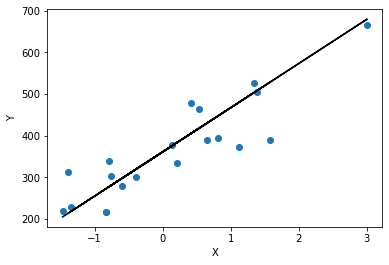

In [36]:
plt.plot(X_test_s[:, [0]], y_test, 'o')
plt.plot(X_test_s[:, [0]], y_prediction, 'k-')
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

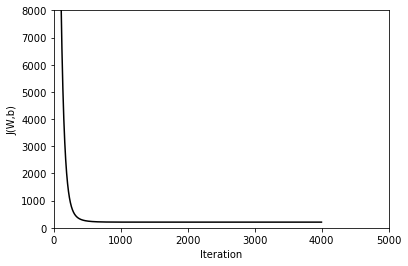

In [37]:
plt.plot(J_h[:4000,[1]], J_h[:4000,[0]], color="black")
plt.xlabel("Iteration")
plt.ylabel("J(W,b)")

plt.xlim([0, 5000])
plt.ylim([0, 8000])

plt.show()

# Finished!